In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aabdollahii/diabetes-ontl/Diabetes_large.owl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/__script__.py
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/matplotlib_inline-0.2.2-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/asttokens-3.0.2-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/pexpect-4.9.0-py2.py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/prompt_toolkit-3.0.53-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/ipython-9.16.1-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/pyparsing-3.3.2-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/__results__.html
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/networkx-3.6.1-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/executing-2.2.1-py2.py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-2026-21-19-57/jinja2-3.1.6-py3-none-any.whl
/kaggle/input/pm-129608092-at-08-03-202

In [2]:
from pathlib import Path
from collections import Counter, defaultdict
import re
import json
import math
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from rdflib import Graph, Namespace, URIRef, BNode, Literal
from rdflib.namespace import RDF, RDFS, OWL, XSD, DC, DCTERMS, SKOS

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

owl_path = Path("/kaggle/input/datasets/aabdollahii/diabetes-ontl/Diabetes_large.owl")

print("Exists:", owl_path.exists())
print("Path:", owl_path)

if not owl_path.exists():
    raise FileNotFoundError(f"File not found: {owl_path}")


Exists: True
Path: /kaggle/input/datasets/aabdollahii/diabetes-ontl/Diabetes_large.owl


In [3]:
g = Graph()

# Parse tries to detect format automatically
g.parse(str(owl_path))

print("Triples:", len(g))
print("Namespaces:", len(list(g.namespaces())))


Triples: 150335
Namespaces: 31


In [4]:
classes = set(g.subjects(RDF.type, OWL.Class)) | set(g.subjects(RDF.type, RDFS.Class))
object_properties = set(g.subjects(RDF.type, OWL.ObjectProperty))
datatype_properties = set(g.subjects(RDF.type, OWL.DatatypeProperty))
annotation_properties = set(g.subjects(RDF.type, OWL.AnnotationProperty))
restrictions = set(g.subjects(RDF.type, OWL.Restriction))
named_individuals = set(g.subjects(RDF.type, OWL.NamedIndividual))
ontology_nodes = set(g.subjects(RDF.type, OWL.Ontology))

schema_resources = classes | object_properties | datatype_properties | annotation_properties | restrictions | ontology_nodes

print("=== Ontology Summary ===")
print("Ontologies:", len(ontology_nodes))
print("Classes:", len(classes))
print("Object properties:", len(object_properties))
print("Datatype properties:", len(datatype_properties))
print("Annotation properties:", len(annotation_properties))
print("Restrictions:", len(restrictions))
print("Named individuals:", len(named_individuals))
print("Total schema-like resources:", len(schema_resources))


=== Ontology Summary ===
Ontologies: 1
Classes: 65
Object properties: 21
Datatype properties: 5
Annotation properties: 1
Restrictions: 0
Named individuals: 21558
Total schema-like resources: 91


In [5]:
def local_name(uri):
    s = str(uri)
    if "#" in s:
        return s.rsplit("#", 1)[-1]
    return s.rstrip("/").rsplit("/", 1)[-1]

def get_label(node):
    for pred in [RDFS.label, SKOS.prefLabel, DC.title, DCTERMS.title]:
        val = g.value(node, pred)
        if val:
            return str(val)
    return local_name(node)

def pretty_node(node):
    if isinstance(node, Literal):
        return f'"{node}"'
    return f"{get_label(node)} [{local_name(node)}]"


In [6]:
ns_df = pd.DataFrame(
    [(prefix, str(uri)) for prefix, uri in g.namespaces()],
    columns=["prefix", "namespace"]
)

ns_df.head(20)


,prefix,namespace
0,brick,https://brickschema.org/schema/Brick#
1,csvw,http://www.w3.org/ns/csvw#
2,dc,http://purl.org/dc/elements/1.1/
3,dcat,http://www.w3.org/ns/dcat#
4,dcmitype,http://purl.org/dc/dcmitype/
5,dcterms,http://purl.org/dc/terms/
6,dcam,http://purl.org/dc/dcam/
7,doap,http://usefulinc.com/ns/doap#
8,foaf,http://xmlns.com/foaf/0.1/
9,geo,http://www.opengis.net/ont/geosparql#


In [7]:
predicate_counts = Counter(p for _, p, _ in g)
subject_counts = Counter(s for s, _, _ in g)
object_counts = Counter(o for _, _, o in g)

pred_df = pd.DataFrame(
    [(str(p), c) for p, c in predicate_counts.most_common(40)],
    columns=["predicate", "count"]
)

pred_df.head(20)


,predicate,count
0,http://www.semanticweb.org/laptop-hp/ontologie...,100030
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,42469
2,http://www.semanticweb.org/laptop-hp/ontologie...,768
3,http://www.semanticweb.org/laptop-hp/ontologie...,768
4,http://www.semanticweb.org/laptop-hp/ontologie...,768
5,http://www.semanticweb.org/laptop-hp/ontologie...,768
6,http://www.semanticweb.org/laptop-hp/ontologie...,768
7,http://www.semanticweb.org/laptop-hp/ontologie...,768
8,http://www.semanticweb.org/laptop-hp/ontologie...,768
9,http://www.semanticweb.org/laptop-hp/ontologie...,768


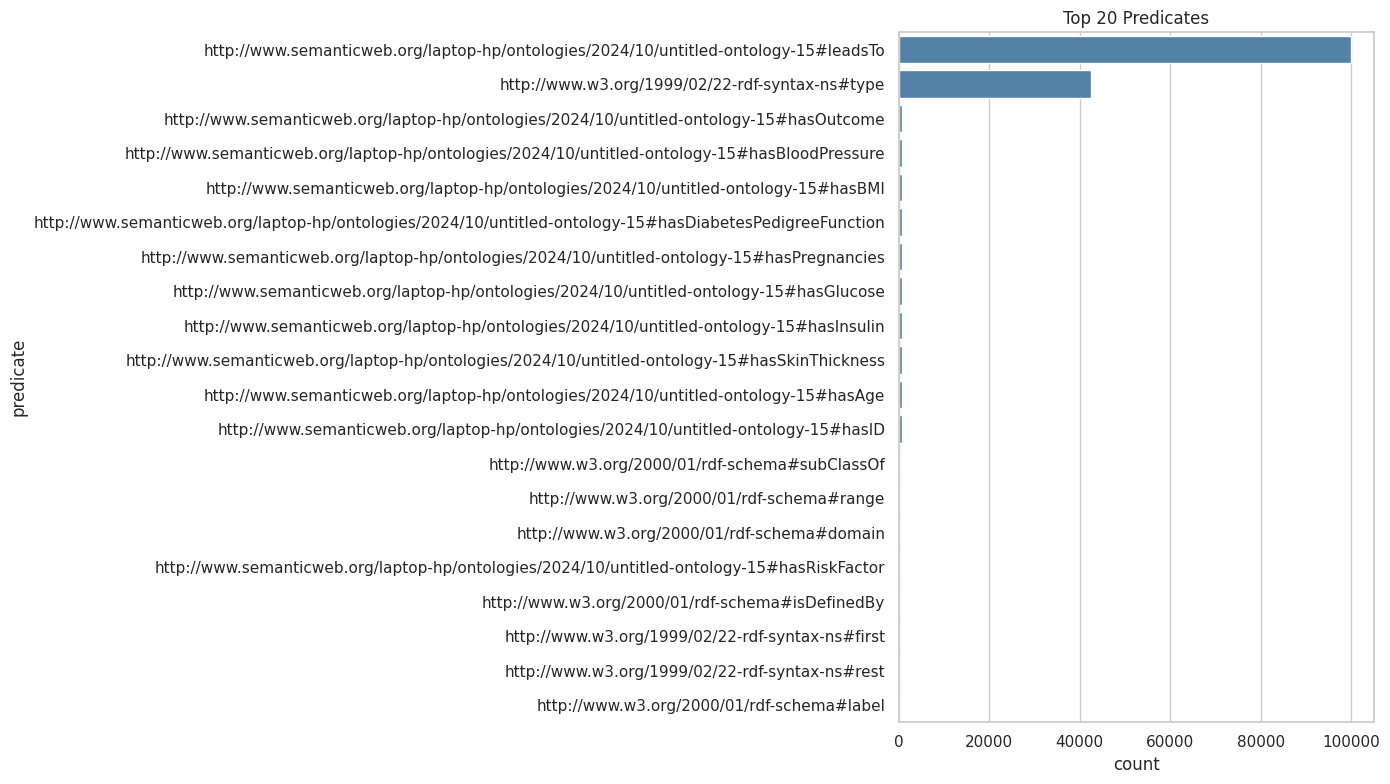

In [8]:
plt.figure(figsize=(14, 8))
sns.barplot(data=pred_df.head(20), y="predicate", x="count", color="steelblue")
plt.title("Top 20 Predicates")
plt.tight_layout()
plt.show()


In [9]:
class_df = pd.DataFrame(
    [(str(c), get_label(c), local_name(c)) for c in sorted(classes, key=lambda x: get_label(x).lower())],
    columns=["uri", "label", "local_name"]
)

objprop_df = pd.DataFrame(
    [(str(p), get_label(p), local_name(p)) for p in sorted(object_properties, key=lambda x: get_label(x).lower())],
    columns=["uri", "label", "local_name"]
)

dataprop_df = pd.DataFrame(
    [(str(p), get_label(p), local_name(p)) for p in sorted(datatype_properties, key=lambda x: get_label(x).lower())],
    columns=["uri", "label", "local_name"]
)

print("Classes:", len(class_df))
print("Object properties:", len(objprop_df))
print("Datatype properties:", len(dataprop_df))


Classes: 65
Object properties: 21
Datatype properties: 5


In [10]:
individuals = set()
for s, p, o in g.triples((None, RDF.type, None)):
    if o not in [OWL.Class, RDFS.Class, OWL.ObjectProperty, OWL.DatatypeProperty, OWL.AnnotationProperty, OWL.Restriction, OWL.Ontology]:
        if isinstance(s, (URIRef, BNode)):
            individuals.add(s)

ind_df = pd.DataFrame(
    [(str(i), get_label(i), local_name(i)) for i in sorted(individuals, key=lambda x: get_label(x).lower() if not isinstance(x, BNode) else str(x)) if isinstance(i, URIRef)],
    columns=["uri", "label", "local_name"]
)

print("Individuals:", len(individuals))
ind_df.head(30)


Individuals: 21559


,uri,label,local_name
0,http://snomed.info/id/70995007,\n Diabetic nephropathy (SNOMED CT)...,70995007
1,http://snomed.info/id/38341003,\n Hypertensive disorder (SNOMED CT...,38341003
2,http://snomed.info/id/22298006,\n Myocardial infarction (SNOMED CT...,22298006
3,http://snomed.info/id/73211009,\n Obesity (SNOMED CT)\n,73211009
4,http://snomed.info/id/230690007,\n Stroke (SNOMED CT)\n,230690007
5,http://snomed.info/id/44054006,\n Type 2 diabetes mellitus (SNOMED...,44054006
6,http://www.semanticweb.org/laptop-hp/ontologie...,0,0
7,http://www.semanticweb.org/laptop-hp/ontologie...,0.078,0.078
8,http://www.semanticweb.org/laptop-hp/ontologie...,0.084,0.084
9,http://www.semanticweb.org/laptop-hp/ontologie...,0.085,0.085


In [11]:
obj_triples = []
for s, p, o in g:
    if p in object_properties and (isinstance(s, (URIRef, BNode)) and isinstance(o, (URIRef, BNode, Literal))):
        obj_triples.append((s, p, o))

obj_rel_df = pd.DataFrame(
    [(pretty_node(s), get_label(p), pretty_node(o)) for s, p, o in obj_triples[:300]],
    columns=["subject", "property", "object"]
)

obj_rel_df.head(50)


,subject,property,object
0,C_SyntheticConcept_009344 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_009345 [C_SyntheticConcept_...
1,C_SyntheticConcept_017492 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_017603 [C_SyntheticConcept_...
2,C_SyntheticConcept_012523 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_012597 [C_SyntheticConcept_...
3,C_SyntheticConcept_007576 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_007687 [C_SyntheticConcept_...
4,C_SyntheticConcept_001539 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_001650 [C_SyntheticConcept_...
5,C_SyntheticConcept_008091 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_008165 [C_SyntheticConcept_...
6,C_SyntheticConcept_011587 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_011735 [C_SyntheticConcept_...
7,C_SyntheticConcept_006809 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_006994 [C_SyntheticConcept_...
8,C_SyntheticConcept_017981 [C_SyntheticConcept_...,leadsTo,C_SyntheticConcept_018129 [C_SyntheticConcept_...
9,509 [509],hasOutcome,0 [0]


In [12]:
data_triples = []
for s, p, o in g:
    if p in datatype_properties:
        data_triples.append((s, p, o))

data_rel_df = pd.DataFrame(
    [(pretty_node(s), get_label(p), str(o)) for s, p, o in data_triples[:300]],
    columns=["subject", "property", "value"]
)

data_rel_df.head(50)


,subject,property,value
0,471 [471],hasBMI,http://www.semanticweb.org/laptop-hp/ontologie...
1,274 [274],hasAge,http://www.semanticweb.org/laptop-hp/ontologie...
2,384 [384],hasAge,http://www.semanticweb.org/laptop-hp/ontologie...
3,253 [253],hasAge,http://www.semanticweb.org/laptop-hp/ontologie...
4,164 [164],hasBMI,http://www.semanticweb.org/laptop-hp/ontologie...
5,366 [366],hasBMI,http://www.semanticweb.org/laptop-hp/ontologie...
6,98 [98],hasBMI,http://www.semanticweb.org/laptop-hp/ontologie...
7,477 [477],hasBMI,http://www.semanticweb.org/laptop-hp/ontologie...
8,351 [351],hasAge,http://www.semanticweb.org/laptop-hp/ontologie...
9,643 [643],hasAge,http://www.semanticweb.org/laptop-hp/ontologie...


In [13]:
subclass_pairs = []
for s, _, o in g.triples((None, RDFS.subClassOf, None)):
    subclass_pairs.append((s, o))

subclass_df = pd.DataFrame(
    [(pretty_node(s), pretty_node(o)) for s, o in subclass_pairs if isinstance(s, (URIRef, BNode)) and isinstance(o, (URIRef, BNode))],
    columns=["subclass", "superclass"]
)

print("Subclass relations:", len(subclass_df))
subclass_df.head(40)


Subclass relations: 42


,subclass,superclass
0,AerobicExercise [AerobicExercise],ExerciseActivity [ExerciseActivity]
1,ResistanceExercise [ResistanceExercise],ExerciseActivity [ExerciseActivity]
2,BorderlineHbA1c [BorderlineHbA1c],HbA1cLevel [HbA1cLevel]
3,DiabeticHbA1c [DiabeticHbA1c],HbA1cLevel [HbA1cLevel]
4,NormalHbA1c [NormalHbA1c],HbA1cLevel [HbA1cLevel]
5,CalorieRestrictedDiet [CalorieRestrictedDiet],DietaryPattern [DietaryPattern]
6,HighSugarDiet [HighSugarDiet],DietaryPattern [DietaryPattern]
7,LowGlycemicIndexDiet [LowGlycemicIndexDiet],DietaryPattern [DietaryPattern]
8,MediterraneanDietPattern [MediterraneanDietPat...,DietaryPattern [DietaryPattern]
9,CardiometabolicRiskStatus [CardiometabolicRisk...,ClinicalConcept [ClinicalConcept]


In [14]:
restriction_details = []

for r in restrictions:
    on_property = g.value(r, OWL.onProperty)
    some_values_from = g.value(r, OWL.someValuesFrom)
    all_values_from = g.value(r, OWL.allValuesFrom)
    has_value = g.value(r, OWL.hasValue)
    min_card = g.value(r, OWL.minCardinality)
    max_card = g.value(r, OWL.maxCardinality)
    exact_card = g.value(r, OWL.cardinality)

    restriction_details.append({
        "restriction": str(r),
        "onProperty": pretty_node(on_property) if on_property else None,
        "someValuesFrom": pretty_node(some_values_from) if some_values_from else None,
        "allValuesFrom": pretty_node(all_values_from) if all_values_from else None,
        "hasValue": pretty_node(has_value) if has_value else None,
        "minCardinality": str(min_card) if min_card else None,
        "maxCardinality": str(max_card) if max_card else None,
        "cardinality": str(exact_card) if exact_card else None,
    })

restriction_df = pd.DataFrame(restriction_details)
restriction_df.head(50)


""


In [15]:
class_definitions = []

for c in classes:
    supers = list(g.objects(c, RDFS.subClassOf))
    equivs = list(g.objects(c, OWL.equivalentClass))
    labels = get_label(c)

    class_definitions.append({
        "class": str(c),
        "label": labels,
        "subClassOf_count": len(supers),
        "equivalentClass_count": len(equivs),
        "subClassOf": [pretty_node(x) for x in supers[:10]],
        "equivalentClass": [pretty_node(x) for x in equivs[:10]],
    })

class_def_df = pd.DataFrame(class_definitions)
class_def_df.sort_values(["subClassOf_count", "equivalentClass_count"], ascending=False).head(30)


,class,label,subClassOf_count,equivalentClass_count,subClassOf,equivalentClass
0,http://www.semanticweb.org/laptop-hp/ontologie...,WeightManagementStatus,1,0,[ClinicalConcept [ClinicalConcept]],[]
1,http://www.semanticweb.org/laptop-hp/ontologie...,HypertensionStage2,1,0,[BloodPressure [BloodPressure]],[]
2,http://www.semanticweb.org/laptop-hp/ontologie...,PregnantPatient,1,0,[Patient [Patient]],[]
3,http://www.semanticweb.org/laptop-hp/ontologie...,NormalBP,1,0,[BloodPressure [BloodPressure]],[]
5,http://www.semanticweb.org/laptop-hp/ontologie...,CardiometabolicRiskStatus,1,0,[ClinicalConcept [ClinicalConcept]],[]
8,http://www.semanticweb.org/laptop-hp/ontologie...,Obese,1,0,[BMI [BMI]],[]
9,http://www.semanticweb.org/laptop-hp/ontologie...,HighSugarDiet,1,0,[DietaryPattern [DietaryPattern]],[]
11,http://www.semanticweb.org/laptop-hp/ontologie...,BorderlineHbA1c,1,0,[HbA1cLevel [HbA1cLevel]],[]
14,http://www.semanticweb.org/laptop-hp/ontologie...,ModeratelyActive,1,0,[PhysicalActivityLevel [PhysicalActivityLevel]],[]
15,http://www.semanticweb.org/laptop-hp/ontologie...,WalkingExercise,1,0,[AerobicExercise [AerobicExercise]],[]


In [16]:
def build_local_graph(center_nodes, hops=1, max_nodes=120):
    H = nx.DiGraph()
    frontier = set(center_nodes)
    visited = set(center_nodes)

    for _ in range(hops):
        next_frontier = set()
        for node in list(frontier):
            for s, p, o in g.triples((node, None, None)):
                if isinstance(o, (URIRef, BNode)):
                    H.add_edge(str(s), str(o), label=get_label(p))
                    if o not in visited:
                        next_frontier.add(o)
                        visited.add(o)
                else:
                    H.add_node(str(s), label=get_label(s), kind="literal")
            for s, p, o in g.triples((None, None, node)):
                if isinstance(s, (URIRef, BNode)):
                    H.add_edge(str(s), str(node), label=get_label(p))
                    if s not in visited:
                        next_frontier.add(s)
                        visited.add(s)
        frontier = next_frontier
        if len(visited) >= max_nodes:
            break

    # remove overly large graphs
    if H.number_of_nodes() > max_nodes:
        keep = list(H.nodes())[:max_nodes]
        H = H.subgraph(keep).copy()

    return H


In [17]:
seed_nodes = []

# اول چند class پراتصال
for c in list(classes)[:5]:
    seed_nodes.append(c)

# اگر فرد داریم، چند نمونه هم اضافه کن
for i in list(individuals)[:5]:
    if isinstance(i, URIRef):
        seed_nodes.append(i)

seed_nodes = [node for node in seed_nodes if isinstance(node, (URIRef, BNode))]
print("Seed nodes:", [pretty_node(n) for n in seed_nodes[:10]])


Seed nodes: ['WeightManagementStatus [WeightManagementStatus]', 'HypertensionStage2 [HypertensionStage2]', 'PregnantPatient [PregnantPatient]', 'NormalBP [NormalBP]', 'Patient [Patient]', 'C_SyntheticConcept_017710 [C_SyntheticConcept_017710]', 'C_SyntheticConcept_009398 [C_SyntheticConcept_009398]', 'C_SyntheticConcept_000635 [C_SyntheticConcept_000635]', 'C_SyntheticConcept_008772 [C_SyntheticConcept_008772]', 'C_SyntheticConcept_019709 [C_SyntheticConcept_019709]']


In [18]:
seed_nodes = []

# اول چند class پراتصال
for c in list(classes)[:5]:
    seed_nodes.append(c)

# اگر فرد داریم، چند نمونه هم اضافه کن
for i in list(individuals)[:5]:
    if isinstance(i, URIRef):
        seed_nodes.append(i)

seed_nodes = [node for node in seed_nodes if isinstance(node, (URIRef, BNode))]
print("Seed nodes:", [pretty_node(n) for n in seed_nodes[:10]])


Seed nodes: ['WeightManagementStatus [WeightManagementStatus]', 'HypertensionStage2 [HypertensionStage2]', 'PregnantPatient [PregnantPatient]', 'NormalBP [NormalBP]', 'Patient [Patient]', 'C_SyntheticConcept_017710 [C_SyntheticConcept_017710]', 'C_SyntheticConcept_009398 [C_SyntheticConcept_009398]', 'C_SyntheticConcept_000635 [C_SyntheticConcept_000635]', 'C_SyntheticConcept_008772 [C_SyntheticConcept_008772]', 'C_SyntheticConcept_019709 [C_SyntheticConcept_019709]']


Graph nodes: 80
Graph edges: 85


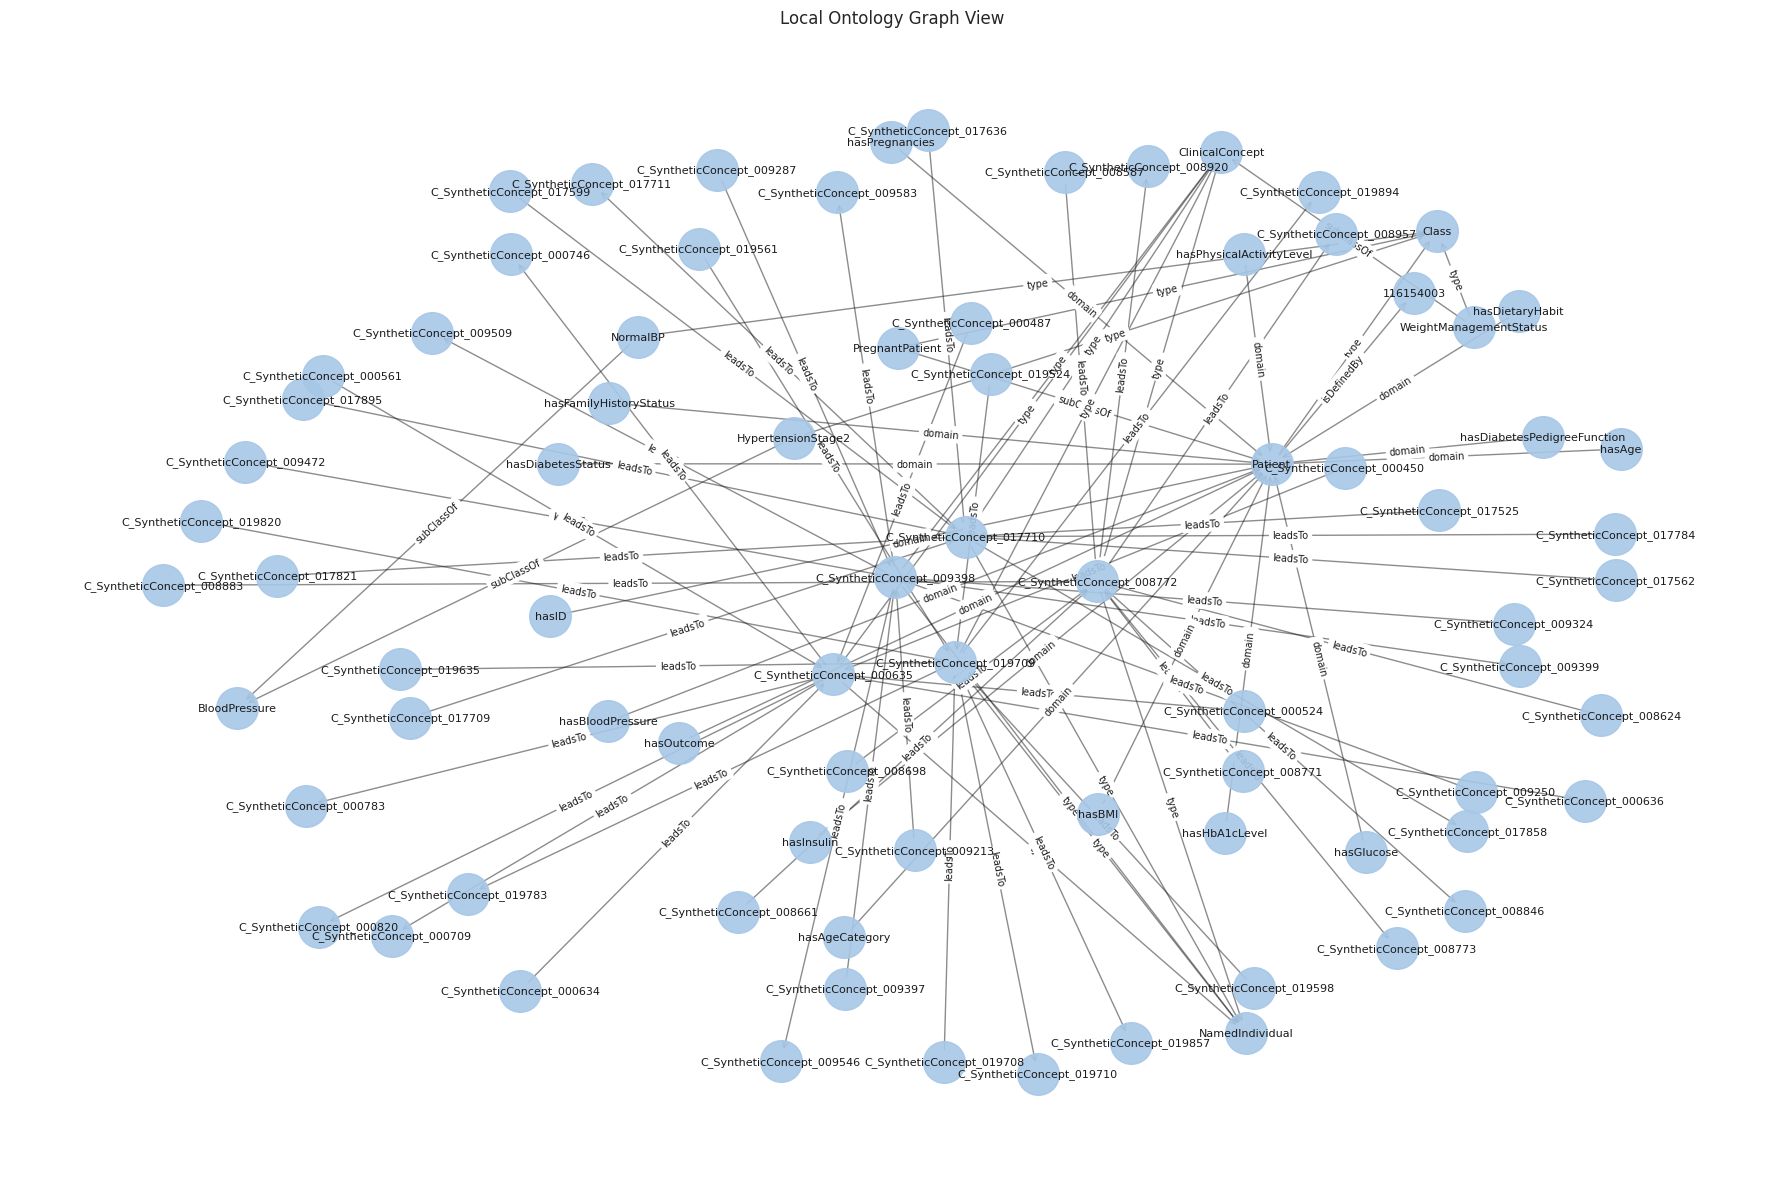

In [19]:
G_vis = build_local_graph(seed_nodes, hops=1, max_nodes=80)

print("Graph nodes:", G_vis.number_of_nodes())
print("Graph edges:", G_vis.number_of_edges())

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G_vis, seed=42, k=0.7)

nx.draw_networkx_nodes(G_vis, pos, node_size=900, node_color="#A7C7E7", alpha=0.9)
nx.draw_networkx_edges(G_vis, pos, arrows=True, arrowstyle="->", width=1.0, alpha=0.5)

labels = {n: local_name(n) for n in G_vis.nodes()}
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

edge_labels = nx.get_edge_attributes(G_vis, "label")
nx.draw_networkx_edge_labels(G_vis, pos, edge_labels=edge_labels, font_size=7)

plt.title("Local Ontology Graph View")
plt.axis("off")
plt.tight_layout()
plt.show()


In [20]:
from pyvis.network import Network
from IPython.display import IFrame, display

def make_pyvis_graph(nx_graph, output_html="ontology_graph.html"):
    net = Network(height="800px", width="100%", directed=True, notebook=True)
    net.barnes_hut()

    for node in nx_graph.nodes():
        label = local_name(node)
        net.add_node(node, label=label, title=node)

    for u, v, data in nx_graph.edges(data=True):
        label = data.get("label", "")
        net.add_edge(u, v, label=label, title=label)

    net.show(output_html)
    return output_html

html_file = make_pyvis_graph(G_vis, "ontology_graph.html")
display(IFrame(html_file, width="100%", height="850px"))


ontology_graph.html


In [21]:
def inspect_resource(resource):
    print("URI:", resource)
    print("Label:", get_label(resource))
    print("Local name:", local_name(resource))
    print("\nTypes:")
    for t in g.objects(resource, RDF.type):
        print(" -", pretty_node(t))

    print("\nOutgoing triples:")
    for p, o in list(g.predicate_objects(resource))[:30]:
        print(" -", get_label(p), "=>", pretty_node(o))

    print("\nIncoming triples:")
    for s, p in list(g.subject_predicates(resource))[:30]:
        print(" -", pretty_node(s), "<=", get_label(p))

# نمونه: اولین کلاس
if len(classes) > 0:
    inspect_resource(list(classes)[0])


URI: http://www.semanticweb.org/laptop-hp/ontologies/2024/10/untitled-ontology-15#WeightManagementStatus
Label: WeightManagementStatus
Local name: WeightManagementStatus

Types:
 - Class [Class]

Outgoing triples:
 - type => Class [Class]
 - subClassOf => ClinicalConcept [ClinicalConcept]

Incoming triples:


In [22]:
tree_edges = []
for s, o in subclass_pairs:
    if isinstance(s, (URIRef, BNode)) and isinstance(o, (URIRef, BNode)):
        tree_edges.append((pretty_node(s), pretty_node(o)))

tree_df = pd.DataFrame(tree_edges, columns=["subclass", "superclass"])
tree_df.head(50)


,subclass,superclass
0,AerobicExercise [AerobicExercise],ExerciseActivity [ExerciseActivity]
1,ResistanceExercise [ResistanceExercise],ExerciseActivity [ExerciseActivity]
2,BorderlineHbA1c [BorderlineHbA1c],HbA1cLevel [HbA1cLevel]
3,DiabeticHbA1c [DiabeticHbA1c],HbA1cLevel [HbA1cLevel]
4,NormalHbA1c [NormalHbA1c],HbA1cLevel [HbA1cLevel]
5,CalorieRestrictedDiet [CalorieRestrictedDiet],DietaryPattern [DietaryPattern]
6,HighSugarDiet [HighSugarDiet],DietaryPattern [DietaryPattern]
7,LowGlycemicIndexDiet [LowGlycemicIndexDiet],DietaryPattern [DietaryPattern]
8,MediterraneanDietPattern [MediterraneanDietPat...,DietaryPattern [DietaryPattern]
9,CardiometabolicRiskStatus [CardiometabolicRisk...,ClinicalConcept [ClinicalConcept]


In [23]:
summary = {
    "triples": len(g),
    "ontologies": len(ontology_nodes),
    "classes": len(classes),
    "object_properties": len(object_properties),
    "datatype_properties": len(datatype_properties),
    "annotation_properties": len(annotation_properties),
    "restrictions": len(restrictions),
    "named_individuals": len(named_individuals),
    "all_individuals_like": len(individuals),
}

summary_df = pd.DataFrame([summary])
summary_df


,triples,ontologies,classes,object_properties,datatype_properties,annotation_properties,restrictions,named_individuals,all_individuals_like
0,150335,1,65,21,5,1,0,21558,21559


In [24]:
class_df.to_csv("classes.csv", index=False)
objprop_df.to_csv("object_properties.csv", index=False)
dataprop_df.to_csv("datatype_properties.csv", index=False)
restriction_df.to_csv("restrictions.csv", index=False)
subclass_df.to_csv("subclass_relations.csv", index=False)
summary_df.to_csv("ontology_summary.csv", index=False)

print("Saved CSV files.")


Saved CSV files.
